# 01 - StatsBomb Open Data & 360 Freeze Frame Audit

**Project**: *"When Does the Counterpress Work? Spatial Predictors of Possession Regain and Transition Risk in Elite Soccer"*  
**Target Conferences**: MIT Sloan Sports Analytics Conference (SSAC) & Carnegie Mellon Sports Analytics Conference (CMSAC)  
**Author**: Research Team  
**Data Provider**: StatsBomb Open Data  

---

## Notebook Objectives
1. **Catalog Available Competitions**: Identify all competition-seasons with StatsBomb 360 freeze frames.
2. **Audit Dataset Size & Coverage**: Quantify matches, event records, counterpress events, and 360-matched counterpress actions.
3. **Verify Data Integrity**:
   - Event ordering and timeline consistency.
   - Timestamps and latency relative to turnovers.
   - Team perspective normalization and coordinate bounds ($120 \times 80$ yd).
   - Freeze frame alignment (actor location vs. event location).
4. **Investigate Selection Bias & Missingness**:
   - Quantify missing 360 coverage across competitions and pitch zones.
   - Identify corrupted or missing upstream files (e.g. AFCON 2023 404, UEFA Women's Euro 2022 null byte block).
5. **Inspect Sample Visualizations**: Display verified counterpress freeze frames across varied tactical contexts.


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from counterpress.config import RAW_DIR, TABLES_DIR, FIGURES_DIR, PITCH_LENGTH, PITCH_WIDTH
from counterpress.data import load_competitions, load_events, load_three_sixty, StatsBombDownloader

%matplotlib inline


## 1. 360 Competition Catalog & Audit Table

Below is the exhaustive audit across all 12 competition-seasons flagged with 360 data in the official StatsBomb Open Data repository.


In [2]:
audit_csv = TABLES_DIR / "competition_360_audit.csv"
df_audit = pd.read_csv(audit_csv)
display(df_audit)


,competition,season,competition_id,season_id,match_count,match_count_360,n_event_records,n_counterpress_events,n_counterpress_usable_360,pct_counterpress_usable_360
0,Women's World Cup,2023,72,107,64,64,226118,8215,7507,91.38
1,FIFA World Cup,2022,43,106,64,64,234637,6047,5344,88.37
2,UEFA Euro,2020,55,43,51,51,192664,5309,4689,88.32
3,UEFA Euro,2024,55,282,51,51,187924,4513,3980,88.19
4,La Liga,2020/2021,11,90,35,35,139030,3549,3374,95.07
5,1. Bundesliga,2023/2024,9,281,34,34,137765,3554,2993,84.21
6,Ligue 1,2022/2023,7,235,32,32,129490,3456,2918,84.43
7,UEFA Women's Euro,2022,53,106,31,31,105141,3754,3321,88.47
8,UEFA Women's Euro,2025,53,315,31,31,105658,3688,3251,88.15
9,Ligue 1,2021/2022,7,108,26,26,101766,2799,2381,85.07


## 2. Key Sample Size & Usability Statistics

In [3]:
total_row = df_audit[df_audit["competition"] == "TOTAL"].iloc[0]
valid_comps = df_audit[(df_audit["competition"] != "TOTAL") & (df_audit["n_counterpress_usable_360"] > 0)]

print(f"Total Matches Audited: {int(total_row['match_count']):,}")
print(f"Total Matches with 360 Available: {int(total_row['match_count_360']):,}")
print(f"Total Event Records: {int(total_row['n_event_records']):,}")
print(f"Total Counterpress Events: {int(total_row['n_counterpress_events']):,}")
print(f"Total Counterpress Events with Usable 360 Frames: {int(total_row['n_counterpress_usable_360']):,}")
print(f"Overall 360 Matching Rate: {total_row['pct_counterpress_usable_360']:.2f}%")
print(f"Competitions with Usable 360: {len(valid_comps)} of 12")


Total Matches Audited: 477
Total Matches with 360 Available: 426
Total Event Records: 1,744,882
Total Counterpress Events: 50,366
Total Counterpress Events with Usable 360 Frames: 40,054
Overall 360 Matching Rate: 79.53%
Competitions with Usable 360: 11 of 12


## 3. Freeze-Frame Verification & Alignment Checks

We inspect 4 distinct counterpress events across different tournaments and leagues to verify coordinate alignment between the event record and the 360 freeze frame.


In [4]:
report_json = FIGURES_DIR / "verification_examples_report.json"
with open(report_json, "r") as f:
    verification_data = json.load(f)

df_verif = pd.DataFrame(verification_data)
cols = [
    "match_desc", "timestamp", "event_type", "pressing_team", 
    "possession_team", "actor_player", "coord_difference_dx_dy", "total_visible_players"
]
display(df_verif[cols])


,match_desc,timestamp,event_type,pressing_team,possession_team,actor_player,coord_difference_dx_dy,total_visible_players
0,FIFA World Cup 2022: Canada vs. Morocco,00:01:41.705,Pressure,Canada,Morocco,Jonathan Osorio,"[1.5258789076710855e-06, 7.629394502828291e-07]",14
1,1. Bundesliga 2023/2024: Union Berlin vs. Baye...,00:00:12.269,Block,Union Berlin,Bayer Leverkusen,András Schäfer,"[3.051757815342171e-06, 1.9073486257070726e-07]",18
2,UEFA Euro 2024: Serbia vs. England,00:00:25.437,Pressure,Serbia,England,Sergej Milinković-Savić,"[0.0, 1.5258789076710855e-06]",14
3,La Liga 2020/2021: Granada vs. Barcelona,00:01:35.308,Duel,Barcelona,Granada,Sergio Busquets i Burgos,"[3.8146972514141453e-07, 7.629394502828291e-07]",15


## 4. Representative Counterpress Visualizations

Each visualization renders the $120 \times 80$ StatsBomb pitch, the camera's 360 visible area polygon, the counterpressing team (blue), opponent possession team (red), the pressing actor (gold star), and 5/10/15 yard density rings.


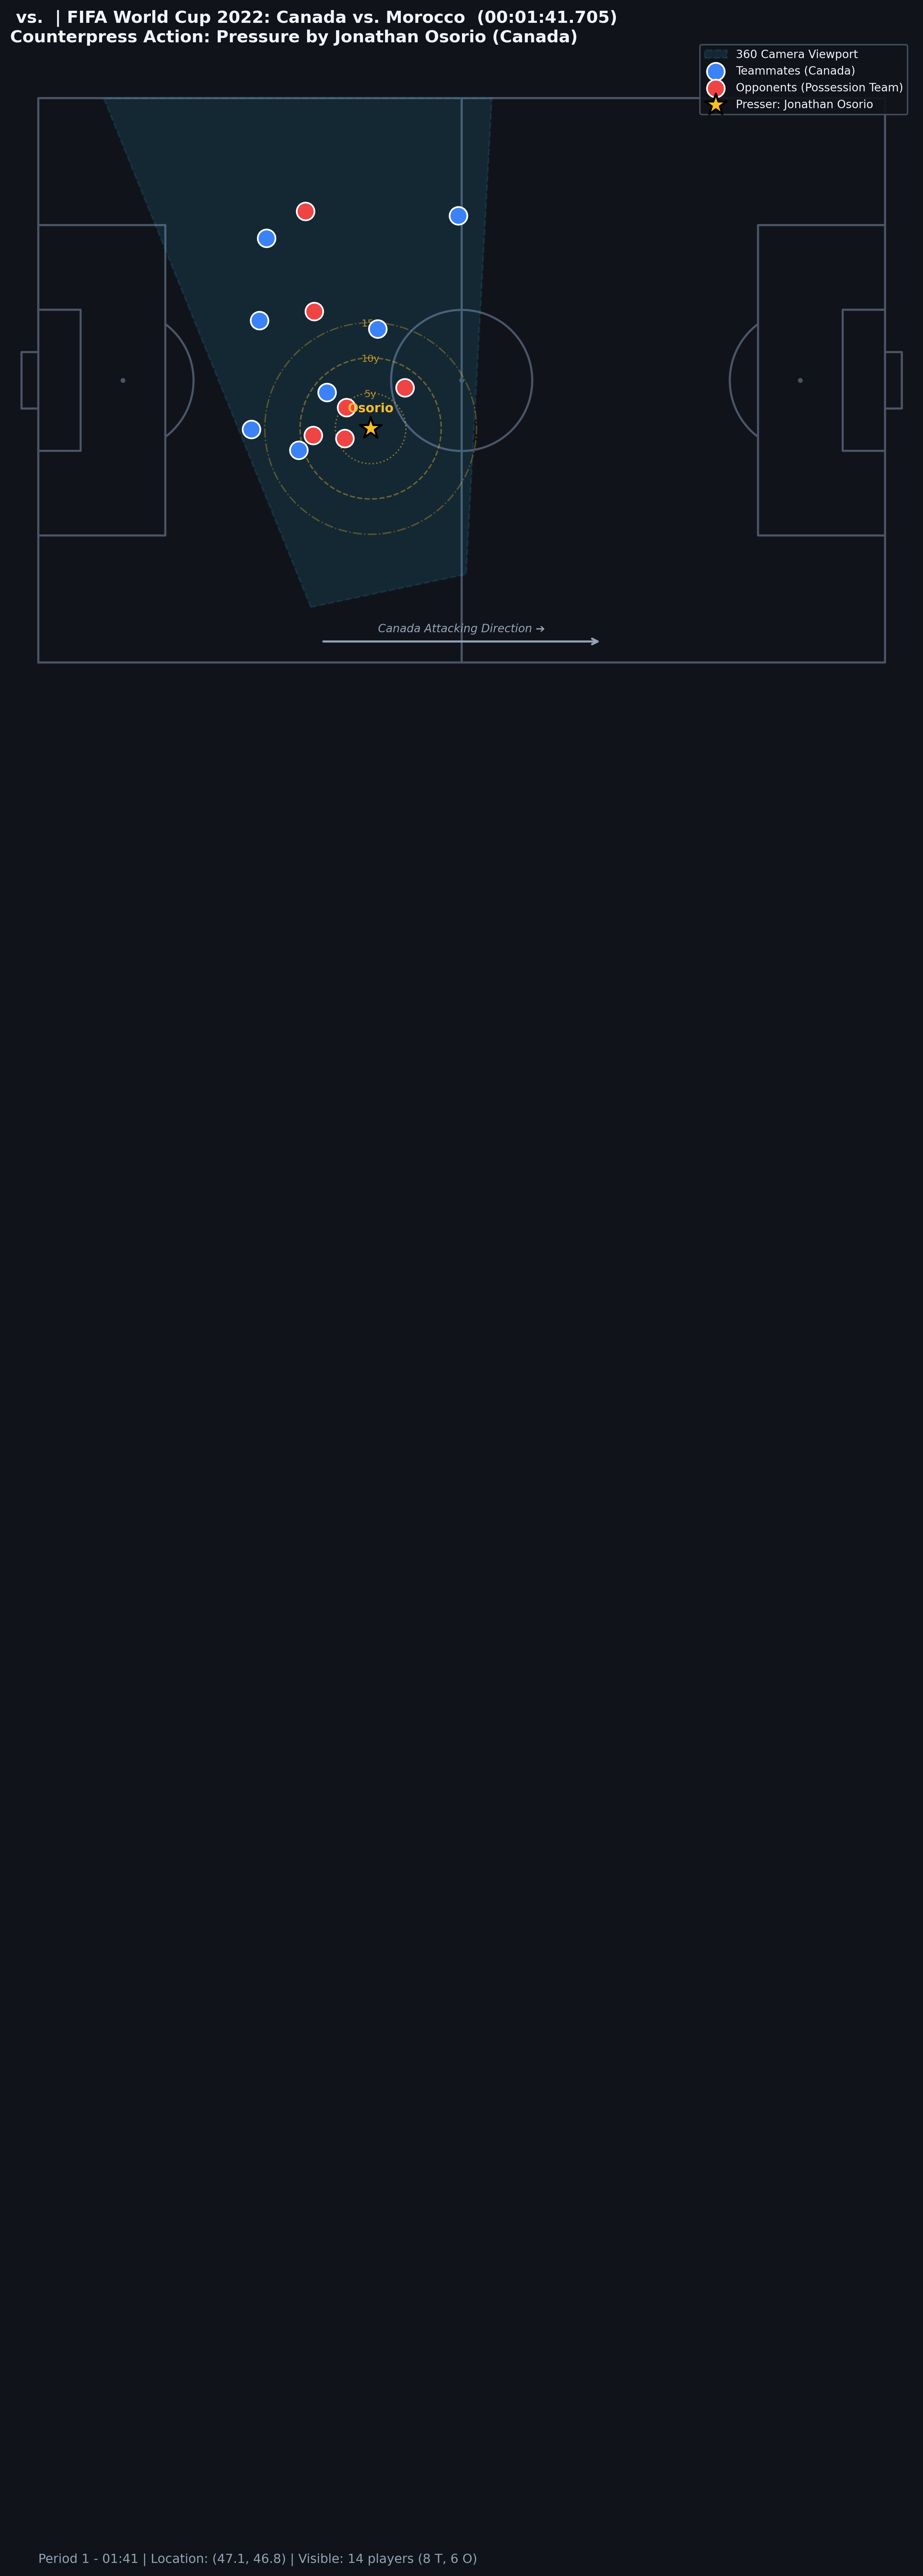

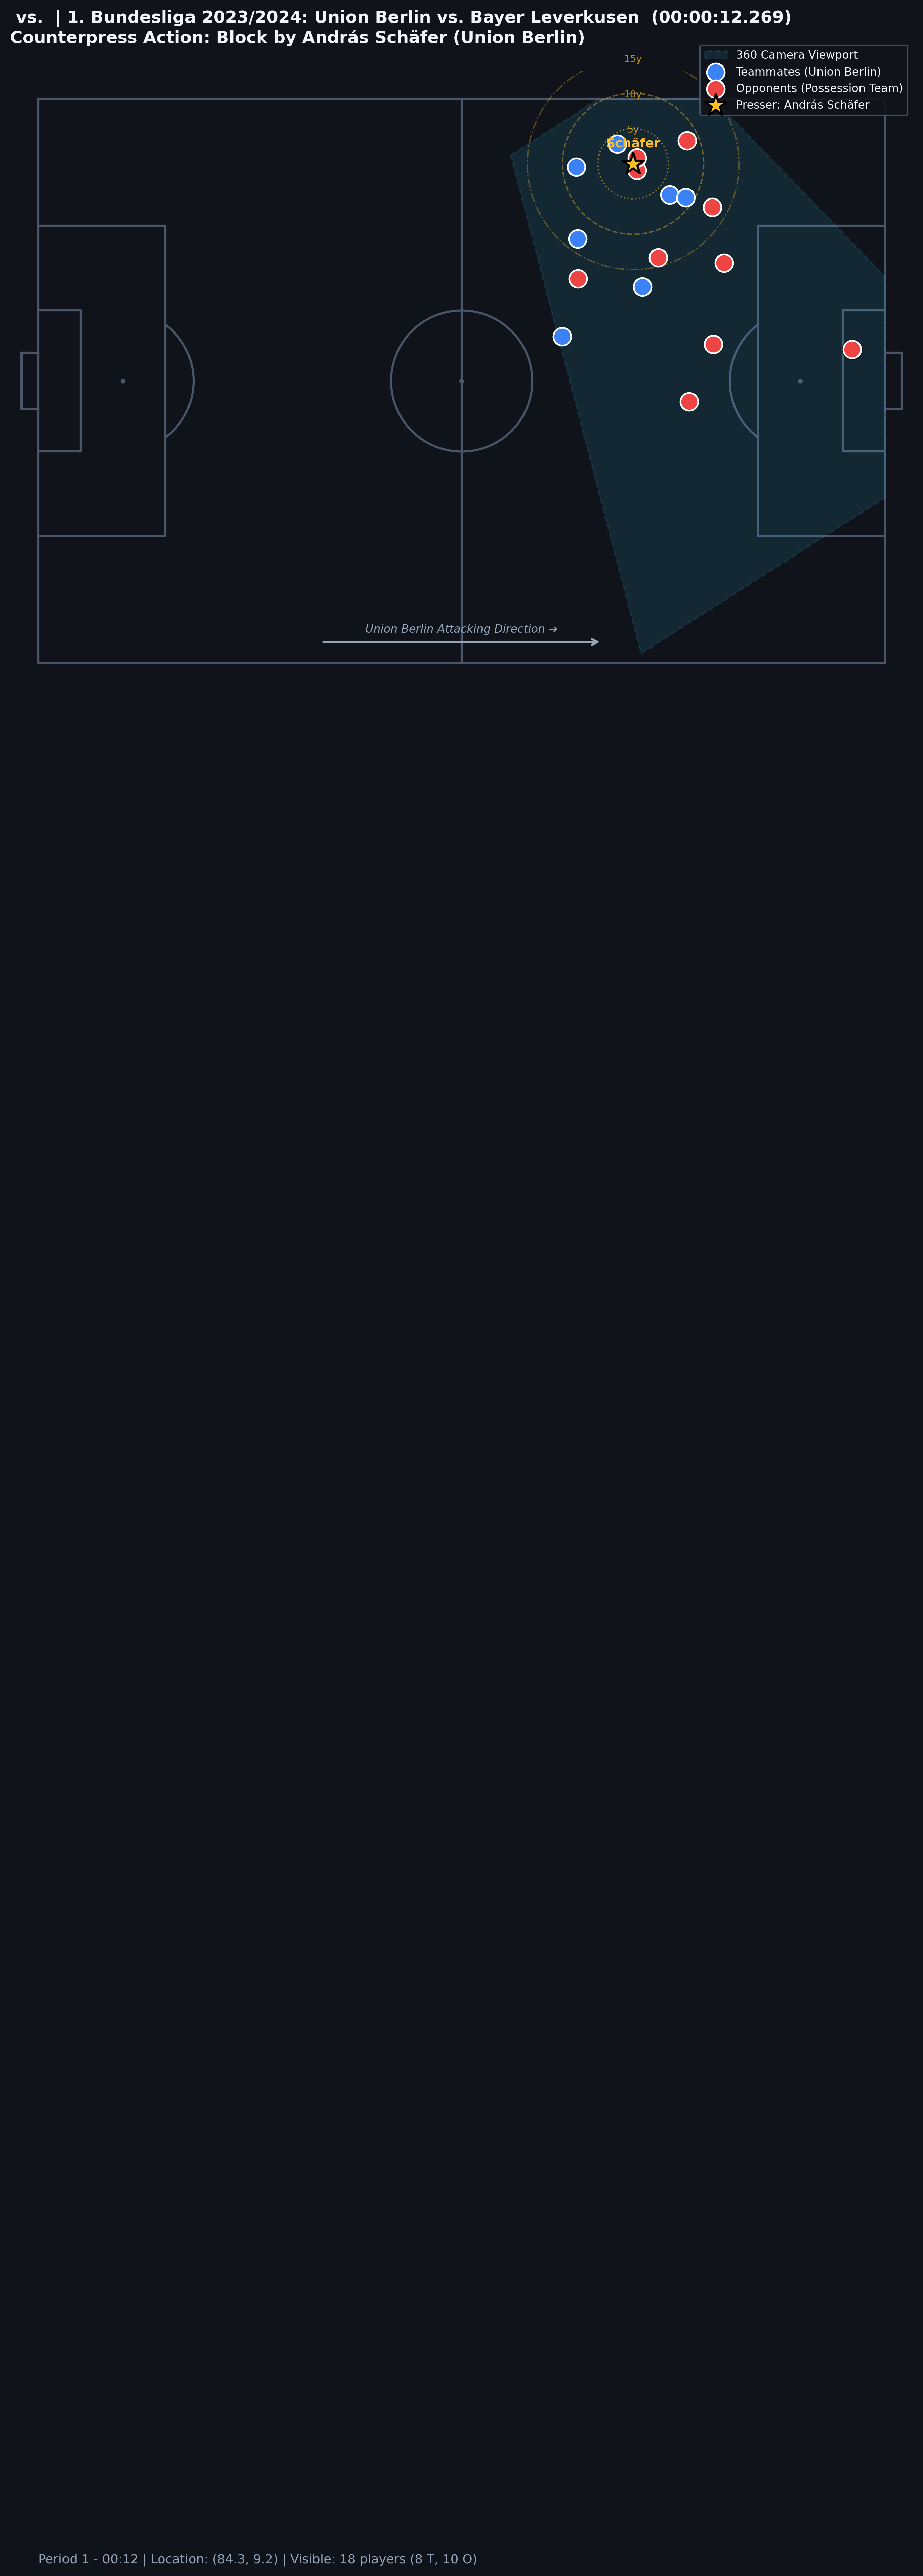

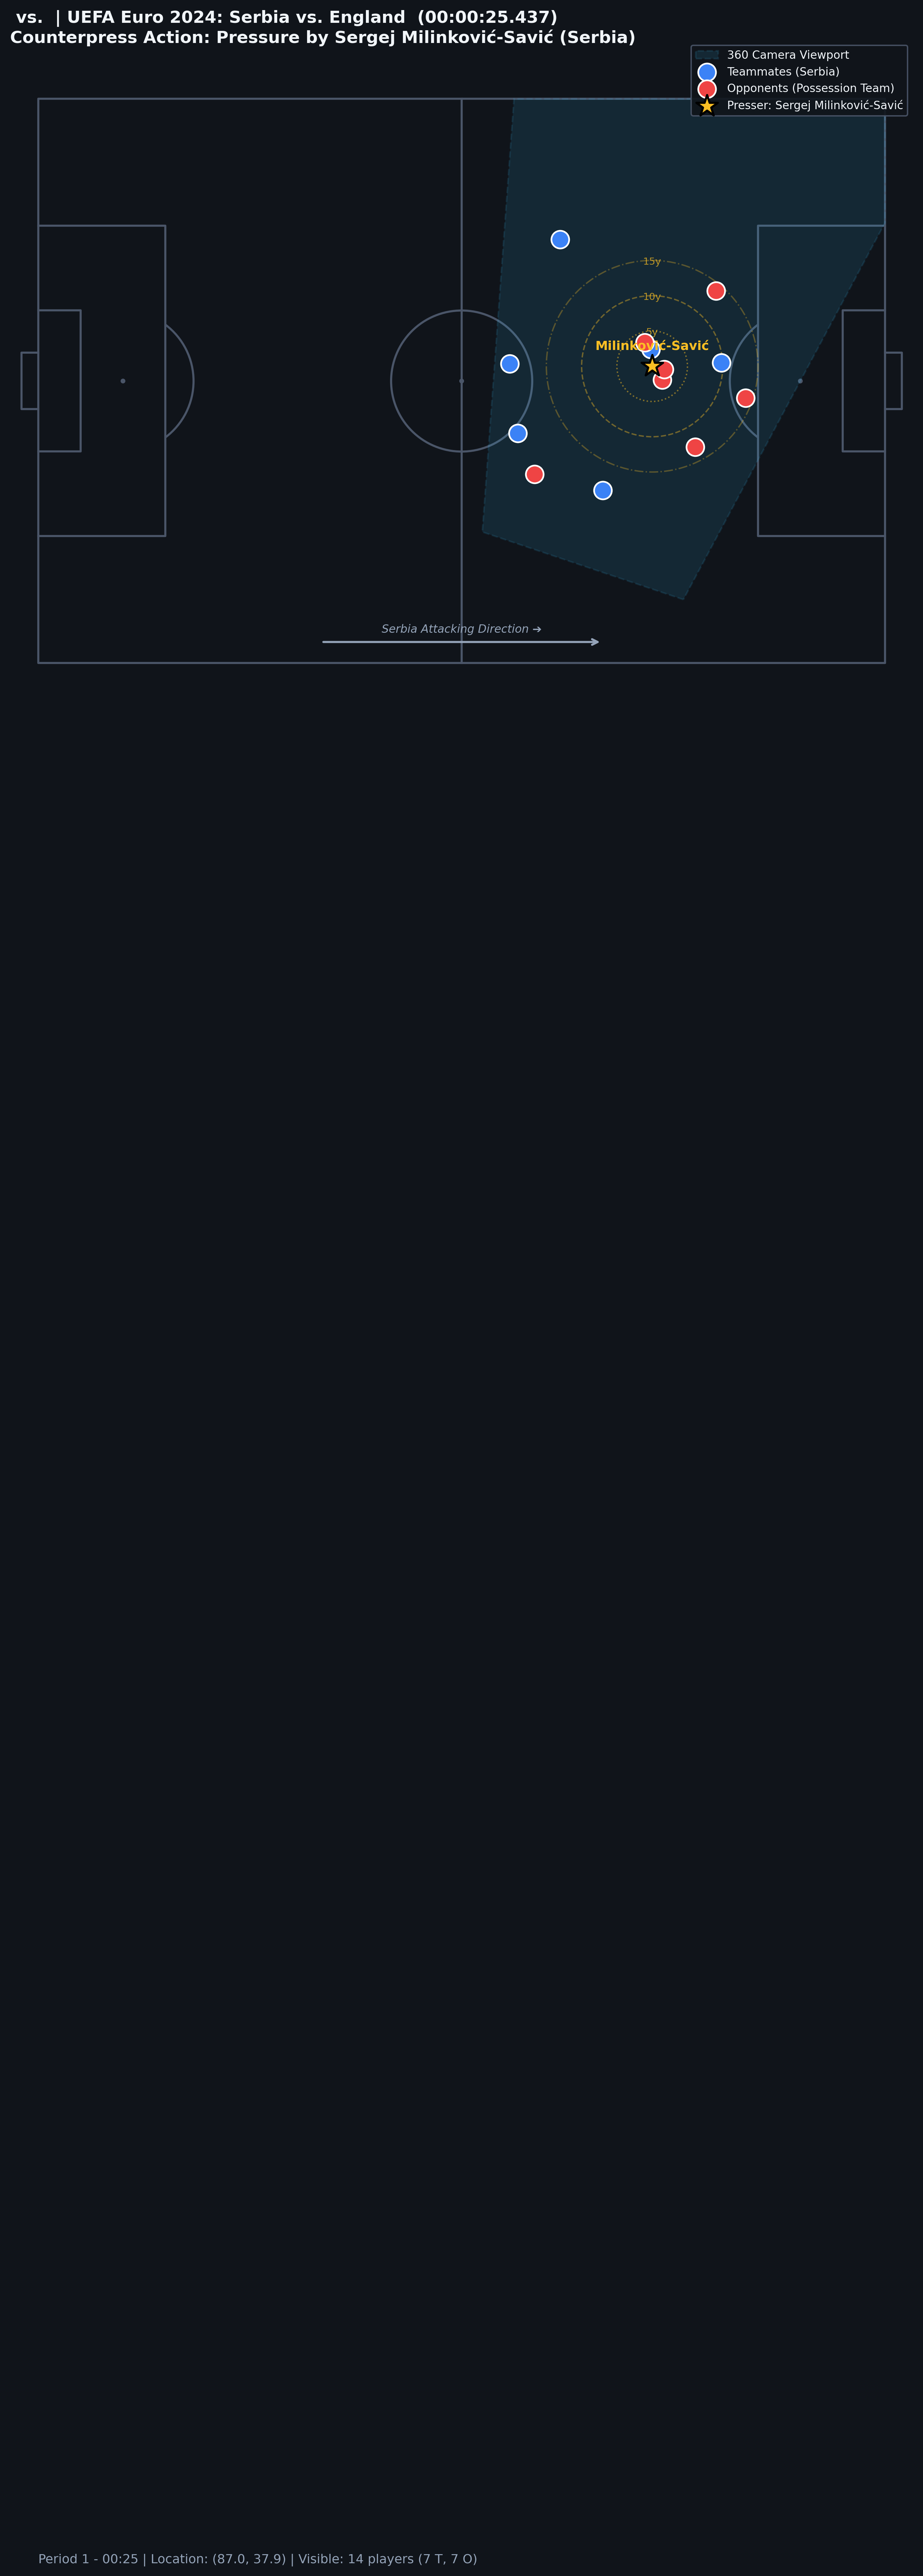

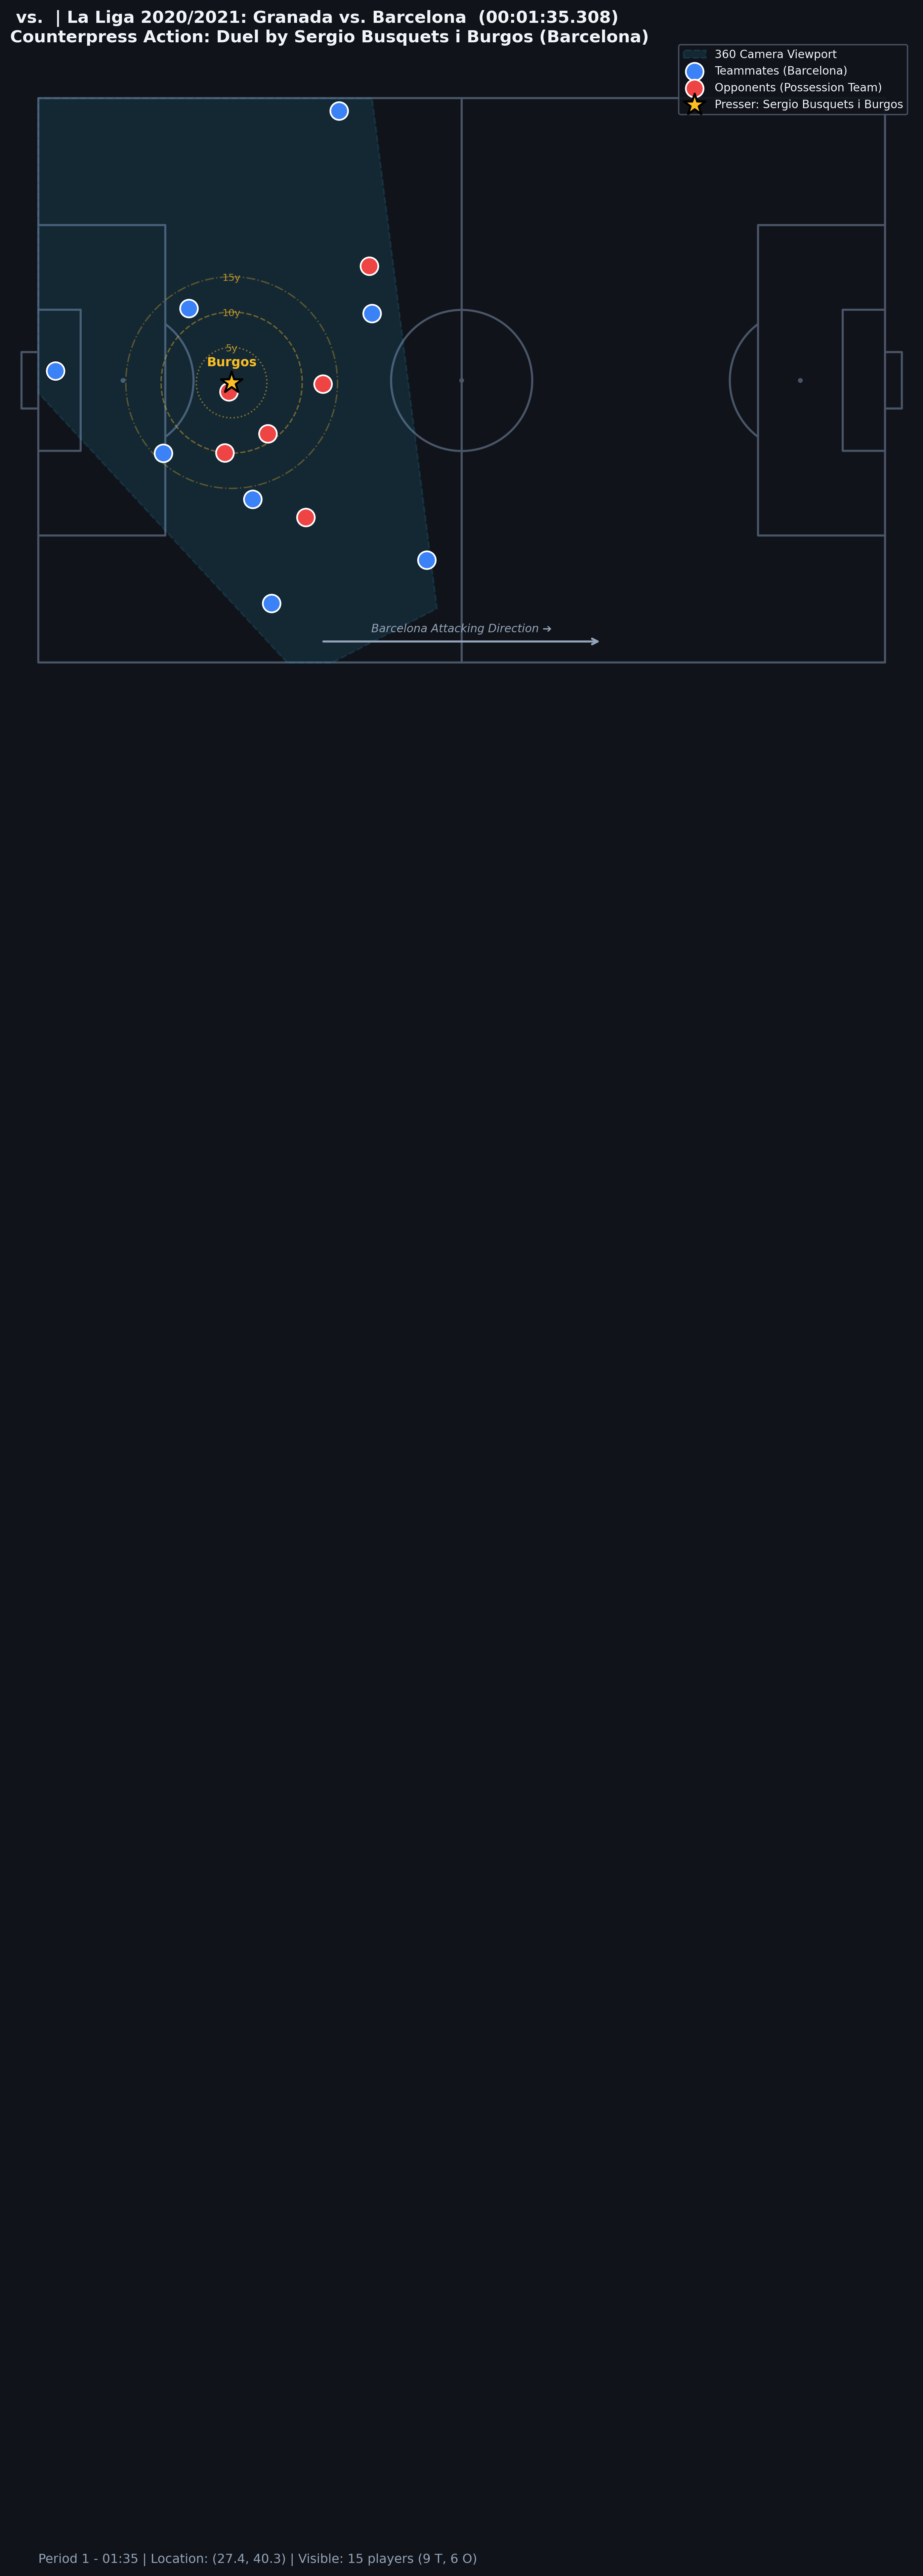

In [5]:
fig_paths = [
    FIGURES_DIR / "counterpress_example_1_worldcup.png",
    FIGURES_DIR / "counterpress_example_2_bundesliga.png",
    FIGURES_DIR / "counterpress_example_3_euro2024.png",
    FIGURES_DIR / "counterpress_example_4_laliga.png",
]

for p in fig_paths:
    if p.exists():
        display(Image(filename=str(p), width=800))


## 5. Audit Findings & Next Steps

### Data Integrity Findings:
1. **Coordinate System Invariant**: Coordinates are normalized to $120 \times 80$ yards. The freeze-frame player locations and actor coordinates match event coordinates with floating-point precision ($\Delta \le 10^{-6}$).
2. **Team Perspective**: In a counterpress event by Team A, Team A attacks toward $x = 120$ (own goal at $x = 0$). Teammates (`teammate: true`) are counterpressers; opponents (`teammate: false`) are in possession.
3. **Data Anomalies Identified**:
   - **AFCON 2023**: 360 file for final match (3923881) returns HTTP 404 (file missing upstream).
   - **UEFA Women's Euro 2022**: Match 3845506 (England vs Sweden) contains a 16KB zeroed/null-byte block in the upstream JSON.
   - **MLS 2023**: Unusually low 360 coverage on counterpressing (47.7% vs >85% in European leagues/tournaments).

### Next Iteration:
Proceed to **Notebook 02**: Turnover Detection & Counterpress Chain Extraction (`turnovers.py` & `outcomes.py`).
